In [1]:
!pip install opendatasets --quiet

In [7]:
# import opendatasets as od
# od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, dataloader
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mssmartypants/rice-type-classification")

# print("Path to dataset files:", path)

In [6]:
# data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")
data_df = pd.read_csv("/content/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
data_df = data_df.dropna()
data_df = data_df.drop(['id'], axis = 1) #removing the id column

In [8]:
data_df.shape

(18185, 11)

In [9]:
data_df['Class'].unique()

array([1, 0])

In [10]:
data_df['Class'].value_counts()

,count
Class,
1,9985
0,8200


In [11]:
# checking for outliers

def detect_outliers_iqr(df, column):
    """
    Identifies outliers using the Interquartile Range (IQR).
    Formula: Lower = Q1 - 1.5*IQR, Upper = Q3 + 1.5*IQR
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(df, column, threshold=3):
    """
    Identifies outliers using Z-score.
    A Z-score tells us how many standard deviations a point is from the mean.
    Default threshold is 3.
    """
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    # We use .index to map back to original dataframe if indices were dropped
    outlier_indices = df.index[np.where(z_scores > threshold)]
    return df.loc[outlier_indices]

def get_outlier_report(df):
    """
    Iterates through all numerical columns and generates a summary report.
    """
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    report = []

    for col in numerical_cols:
        # Using IQR as default for the report as it's more robust
        outliers, lb, ub = detect_outliers_iqr(df, col)

        report.append({
            "Column": col,
            "Total Rows": len(df),
            "Outlier Count": len(outliers),
            "Percentage": f"{(len(outliers) / len(df)) * 100:.2f}%",
            "Min Value": df[col].min(),
            "Max Value": df[col].max(),
            "Lower Bound": lb,
            "Upper Bound": ub
        })

    return pd.DataFrame(report)

def visualize_outliers(df, column):
    """
    Creates a distribution plot and a boxplot side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Boxplot is the industry standard for seeing outliers
    sns.boxplot(x=df[column], ax=axes[0], palette="Set2")
    axes[0].set_title(f'Boxplot of {column}')

    # Histogram to see distribution shape
    sns.histplot(df[column], kde=True, ax=axes[1], color="skyblue")
    axes[1].set_title(f'Distribution of {column}')

    plt.tight_layout()
    plt.show()

In [12]:
print("--- Outlier Summary Report ---")
report_df = get_outlier_report(data_df)
report_df

--- Outlier Summary Report ---


,Column,Total Rows,Outlier Count,Percentage,Min Value,Max Value,Lower Bound,Upper Bound
0,Area,18185,0,0.00%,2522.000000,10210.000000,2270.500000,12114.500000
1,MajorAxisLength,18185,538,2.96%,74.133114,183.211434,124.105454,181.626671
2,MinorAxisLength,18185,0,0.00%,34.409894,82.550762,23.247988,98.301756
3,Eccentricity,18185,136,0.75%,0.676647,0.966774,0.816984,1.016005
4,ConvexArea,18185,0,0.00%,2579.000000,11008.000000,2345.000000,12425.000000
5,EquivDiameter,18185,16,0.09%,56.666658,114.016559,62.477921,128.207881
6,Extent,18185,0,0.00%,0.383239,0.886573,0.302828,0.931366
7,Perimeter,18185,315,1.73%,197.015000,508.511000,275.470500,431.522500
8,Roundness,18185,14,0.08%,0.174590,0.904748,0.473485,0.946757
9,AspectRation,18185,0,0.00%,1.358128,3.911845,1.075166,4.097461


/tmp/ipython-input-1887592206.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[column], ax=axes[0], palette="Set2")


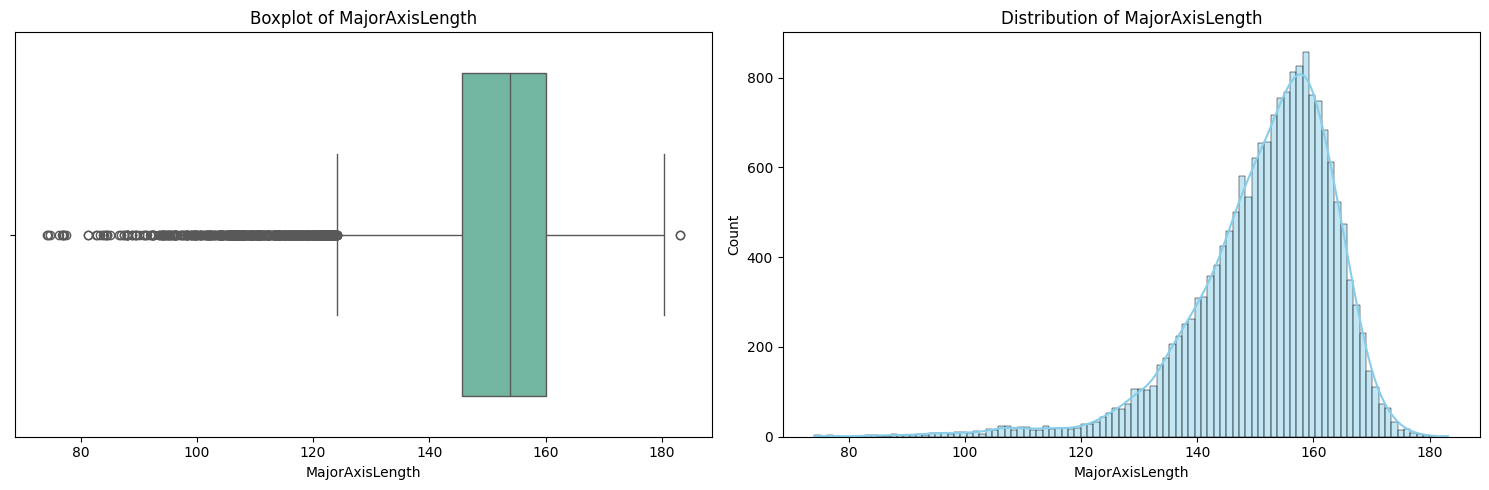

In [13]:
# Visual check
visualize_outliers(data_df, 'MajorAxisLength')

In [14]:
# normalizing the values --  Using normalization since we don't have much outliers to worry about
original_df = data_df.copy()

# Initialize the scaler
scaler = MinMaxScaler()

# This returns a NumPy array, so we wrap it back in a DataFrame
data_df = pd.DataFrame(
    scaler.fit_transform(data_df),
    columns=data_df.columns,
    index=data_df.index
)

In [14]:
data_df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.262097,0.165901,0.614922,0.149139,0.248903,0.337191,0.544960,0.244209,0.807934,0.032371,1.0
1,0.045525,0.005123,0.352934,0.168567,0.051726,0.066336,0.655171,0.036283,0.899898,0.037204,1.0
2,0.068418,0.019803,0.366292,0.188069,0.065607,0.098164,0.746848,0.041724,0.950265,0.042222,1.0
3,0.071670,0.026591,0.363903,0.213671,0.068573,0.102609,0.795277,0.043795,0.952688,0.049077,1.0
4,0.152315,0.100769,0.456247,0.250355,0.145094,0.207586,0.767156,0.106958,0.958906,0.059471,1.0
...,...,...,...,...,...,...,...,...,...,...,...
18180,0.433273,0.682917,0.345224,0.904994,0.406810,0.517174,0.229182,0.436426,0.669518,0.608684,0.0
18181,0.658559,0.875159,0.492965,0.905642,0.620121,0.725477,0.524943,0.605115,0.639275,0.610397,0.0
18182,0.499870,0.739322,0.384251,0.906891,0.468858,0.581631,0.353738,0.466260,0.696071,0.613720,0.0
18183,0.447190,0.708342,0.354474,0.909189,0.428283,0.530871,0.216874,0.469849,0.630873,0.619915,0.0


In [15]:
X = np.array(data_df.drop(['Class'], axis = 1))
y = np.array(data_df['Class'])

### Data Splitting:

We will detect the inputs and the outputs of the data which are X and Y respectively.

Then we will split our data into the following:

- Training Size 70%
- Validation Size 15%
- Testing Size 15%

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [17]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


### Dataset Object
Now we will create the dataset object. This part is not complex but its a bit tricky. We need to convert our dataset to PyTorch Dataset object as it will be more efficient during training, you can use the dataset as its, but lets keep things professional and efficient. First we define our class that will be taking the main Dataset class with the concept of inheritance. Let's make the concept simpler. There is a big class that PyTorch, this class has several functions inside it, we will recreate that class and modify some functions to match our needs.

In the cell below, we rebuilt the constructor function which is `__init__`. We put X and Y as a parameters to this function which are the inputs and outputs respectively, then inside the function we define the inputs and converting it to tensors, then converting the outputs to tensors and we make the numbers as a `float32` Additionally, we moved all our data to cuda device. Then we modified the `__len__` and the `__getitem__` to match our needs which gets the specific length/shape of the data, and the data of specific row in our data respectively.

In [32]:
# class dataset(Dataset):
#   def __init__(self, X, y):
#     self.X = torch.tensor(X, dtype = torch.float32) # include .to(device) if using GPU
#     self.y = torch.tensor(y, dtype = torch.long) # include .to(device) if using GPU

#   def __len__(self):
#     return len(self.X)

#   def __getitem__(self, idx):
#     return self.X[idx], self.y[idx]



class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype = torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [33]:
training_data = dataset(X_train, y_train)
testing_data = dataset(X_test, y_test)
validation_data = dataset(X_val, y_val)

In [37]:
BATCH_SIZE = 32
EPOCHS = 10
HIDDEN_NEURONS = 10
LR = 1e-3

### Data Loaders
This concept may seem complicated, but its very easy, PyTorch provides a class called DataLoader which allows us to create objects of it to simplify the training.

Dataloader is an object that we can loop through it to train according to batches. When we start training, we loop through epochs, if you skip the batch size it means that the amount of training data in one batch is equal to the complete amount of training data, this method is not efficient and in most of the cases you need to train through using batches. Dataloader allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the shuffle to randomize the data and then you can loop through it in each epoch to train normally.

In the next cell, we defined a dataloader for each of our data (training, validation and testing).

In [36]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle= True)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle= True)

### Model Class
Creating a model in PyTorch seems not very straight forward in the beggining, but if you understand how machine learning and deep learning works, it will be easy for you to understand PyTorch structure easily.

In the next cell we define a new class `MyModel` that inherits from nn.Module like we did for the dataset. Remember, in simple terms, we want to redefine some functions in the class to match our needs. In the constructor which is `__init__` and we give it the bert model. Then `super(MyModel, self).__init__()` This line calls the constructor of the parent class `nn.Module` to ensure it's properly initialized. Which means we have the original constructor together with our part of it!

Then, we create our layers, a linear layer which represents the input and having the input size of 10 which is the number of columns of the input and the output of the number of hidden neurons, next layer is the output layer which have the input of hidden neurons and one output since we have a binary classification. Finally we have the activation function which is the sigmoid. Our model is pretty simple and straight forward, we are using a simple dataset and we just want to see how PyTorch can be used to build that.

In the function forward, this function is the forward propagation of the model, how is the data flowing inside the model from the input to the output. This means we can control this completely. That's how PyTorch is so customizable! In the below cell, we define the flow as follows, starting by input layer and followed by the output layer then the activation layer.

In [38]:
class MyModel(nn.Module):
    def __init__(self):

        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

In [39]:
model = MyModel().to(device)
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In the next cell, we will create the loss function which will be Binary Cross entropy and the optimizer Adam which will take the model parameters/weights and the learning rate.

In [40]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr= LR)

## Training

Now comes the exciting part. As we mentioned several times, nothing is complex here if you know how deep learning works. You just need to know PyTorch syntax. We start by initializing the for loop with the specified number of epochs. But before that we define 4 lists and inside the loop we define another 4 variables.

**Variables**:
- `total_acc_train`: here we will keep tracking of the training accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch.

- `total_loss_train`: here we will keep tracking of the training loss progress during each epoch, we calculate the accuracy during the batch size and we use the loss value to optimize and modify the model parameters.

- `total_acc_val`: here we will keep tracking of the validation accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch and help us know if there is any overfitting.

- `total_loss_val`: here we will keep tracking of the validation loss progress during each epoch, we calculate the accuracy during the batch size.

**Lists**:

- `total_acc_train_plot`: We append the losses of the training accuracy to visualize them at the end.

- `total_loss_train_plot`: We append the losses of the training to visualize them at the end.

- `total_acc_validation_plot`: We append the losses of the validation accuracy to visualize them at the end.

- `total_loss_validation_plot`: We append the losses of the validation to visualize them at the end.

**Training**

Then, we start to loop through the training dataloaders, we use the enumerate functionality to loop through data and indices at the same time. We are not using the indices here, but lets kept it just if you want to try different stuff with the loop or debug. In the second loop, we start by getting our data from the data loader, then we move the inputs and labels to the cuda device. We allow the model to make a prediction or what is called forward propagation, then we get the output of the model and compare it with our original output using the loss criteration. We use the squeeze function to modify the shape of the output and make it returns a tensor with all specified dimensions of input of size 1 removed. We add the loss amount to total_loss_train. Additionally, we get the accuracy by comparing the correct batch with the predicted batch and we add it to the total_acc_train. Then we do the `batch_loss.backward()` which makes the backpropagation and we use the optimizer to do a step on the weights using `optimizer.step()` and then we reset the optimizer gradients using `optimizer.zero_grad()` which is a very important step that has to be done before proceeding.

**Validation**

After that we exit the batch loop (train dataloader loop) and we start with the validation. Don't forget that we are still in the same epoch. In side that we start by with `torch.no_grad()` which means that we need the model to do predicitons without being trained. We just need to see the validation preformance. Then we do the same steps which are predicting and calculating loss and accuracy and storing these values.

At the end we print after each epoch the epoch number, training loss, training accuracy, validation loss and validation accuracy.



In [41]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0
    ## Training and Validation
    for data in train_dataloader:

        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    ## Validation
    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)

Epoch no. 1 Train Loss: 0.1898 Train Accuracy: 92.8667 Validation Loss: 0.0210 Validation Accuracy: 98.2038
Epoch no. 2 Train Loss: 0.0590 Train Accuracy: 98.3188 Validation Loss: 0.0080 Validation Accuracy: 98.4604
Epoch no. 3 Train Loss: 0.0305 Train Accuracy: 98.5073 Validation Loss: 0.0055 Validation Accuracy: 98.4604
Epoch no. 4 Train Loss: 0.0233 Train Accuracy: 98.4524 Validation Loss: 0.0049 Validation Accuracy: 98.2771
Epoch no. 5 Train Loss: 0.0205 Train Accuracy: 98.4602 Validation Loss: 0.0043 Validation Accuracy: 98.3504
Epoch no. 6 Train Loss: 0.0192 Train Accuracy: 98.5859 Validation Loss: 0.0042 Validation Accuracy: 98.3138
Epoch no. 7 Train Loss: 0.0183 Train Accuracy: 98.5309 Validation Loss: 0.0041 Validation Accuracy: 98.3504
Epoch no. 8 Train Loss: 0.0179 Train Accuracy: 98.5152 Validation Loss: 0.0041 Validation Accuracy: 98.3871
Epoch no. 9 Train Loss: 0.0176 Train Accuracy: 98.5388 Validation Loss: 0.0042 Validation Accuracy: 98.2771
Epoch no. 10 Train Loss: 0.0

### Testing

Now in this section, we will be testing our model, we will start the code by with `torch.no_grad():` which means that we are telling PyTorch that we don't want to train the model we will be using it only for testing. Then we will declare initial loss and accuracy as zeros, we will start by looping through the testing dataloader like we did before during training. Inside the loop, we got our data and we moved it to our GPU (cuda) and then we ran our model on the data and we got the predictions. After that we get the loss and then we add it to our overall loss, we do the same for accuracy, and finally we print the accuracy.

In [42]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 98.94%


### Plotting and Visualization


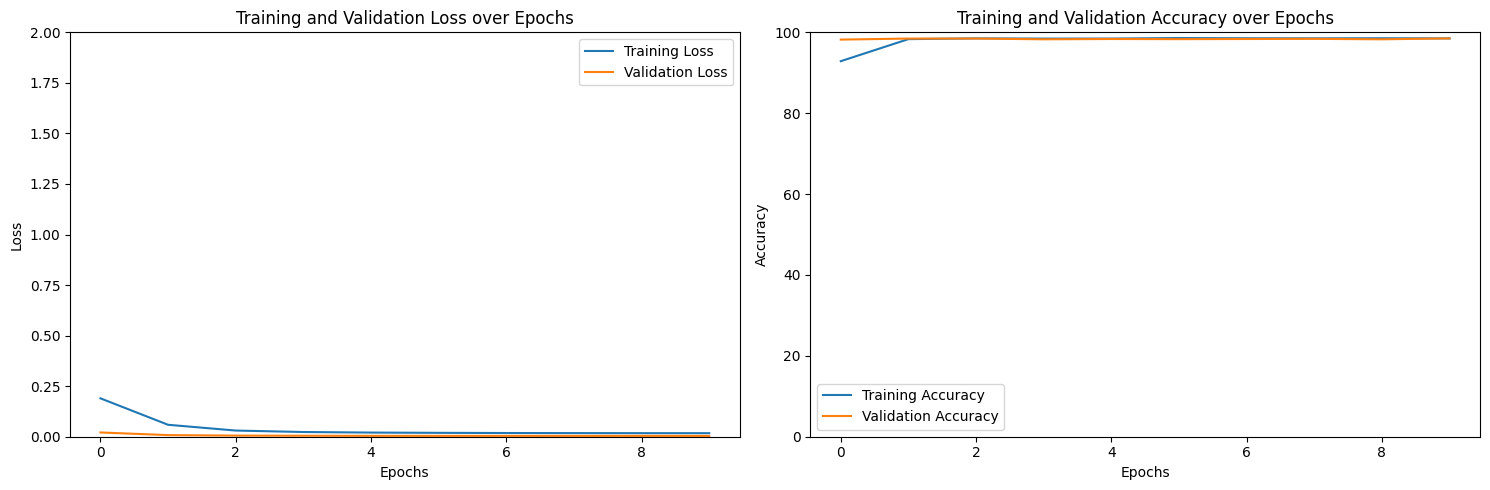

In [43]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

## Inference

Now lets see how we can use the model in inference mode.

In [44]:
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

Area: 6431.279
Major Axis Length: 145.21338
Minor Axis Length: 56.902
Eccentricity: 0.919981821
Convex Area: 6518.93759999
EquivDiameter: 90.483541
Extent: 0.8506668
Perimeter: 329.972
Roundness: 0.742255516
AspectRation: 2.551696
tensor([0.4207], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  0
